<a href="https://colab.research.google.com/github/NikitaMarnykh/labor_market_analysis/blob/main/%D0%9C%D0%B0%D1%80%D0%BD%D1%8B%D1%85_%D0%9D_%D0%92_%D0%B8_%D0%9E%D0%B1%D0%BE%D1%80%D0%BE%D1%82%D0%BE%D0%B2_%D0%9C_%D0%92_%D1%80%D1%8B%D0%BD%D0%BE%D0%BA_%D1%82%D1%80%D1%83%D0%B4%D0%B0_%D0%B0%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7_%D0%B2%D0%B7%D0%B0%D0%B8%D0%BC%D0%BE%D1%81%D0%B2%D1%8F%D0%B7%D0%B8_%D0%BA%D0%B0%D1%82%D0%B5%D0%B3%D0%BE%D1%80%D0%B8%D0%B0%D0%BB%D1%8C%D0%BD%D0%BE%D0%B3%D0%BE_%D0%B8_%D0%BA%D0%BE%D0%BB%D0%B8%D1%87%D0%B5%D1%81%D1%82%D0%B2%D0%B5%D0%BD%D0%BD%D0%BE%D0%B3%D0%BE_%D0%BF%D1%80%D0%B8%D0%B7%D0%BD%D0%B0%D0%BA%D0%BE%D0%B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Признаки, которые будут использованы для дальнейшего анализа**

Количественные признаки:
  
  - идентификатор вакансии (id)

  - минимальная заработная плат (salary_from)
  
  - максимальная заработная плата (salary_to)

Категориальные признаки:

  - профессиональная роль (professional roles)

  - ключевые навыки (key_skills)

  - наименование работодателя (employer)

  - опыт работы (experience)

  - график работы (schedule)

  - тип занятости (employment)

  - доступна ли вакансия для соискателей с инвалидностью (accept_handicapped)

  - город (city)

  - сфера деятельности (field_of_activity)

## 15. Установка и подключение зависимостей для анализа взаимосвязи категориального и количественного признаков

Устанавливаем все необходимые зависимости

In [11]:
!pip install numpy
!pip install matplotlib
!pip install pandas
!pip install scipy
!pip install seaborn

Подключаем все необходимые зависимости

In [12]:
import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import scipy.stats as stats

import seaborn as sns

Подгружаем репозиторий для работы с ним

In [13]:
!git clone https://github.com/NikitaMarnykh/labor_market_analysis

Cloning into 'labor_market_analysis'...
remote: Enumerating objects: 73, done.
remote: Counting objects: 100% (73/73), done.
remote: Compressing objects: 100% (70/70), done.
remote: Total 73 (delta 40), reused 9 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (73/73), 56.06 MiB | 7.03 MiB/s, done.
Resolving deltas: 100% (40/40), done.


Перейдём в установленный репозиторий

In [14]:
%cd labor_market_analysis/

/content/labor_market_analysis/labor_market_analysis


Сохраним датасет в переменную

In [15]:
dataset = pd.read_csv('cleaned_hh_hard.csv',
                      na_values=['NA', 'N/A', 'null', 'missing', '-', '?', '...'],
                      keep_default_na=True,
                      na_filter=True)

## 16. Анализ взаимосвязи категориального и количественного признаков

### 16.1 Признаки salary_from и professional_roles

**Нулевая гипотеза (H₀): распределения двух независимых выборок идентичны. Уровень значимости полагаем равным 0,05**

Сохраним именна переменных в кортеж columns

In [16]:
columns = ('salary_from', 'professional_roles')

Оценим медианные значения данного количественного признака в разрезе данного категориального

In [17]:
dataset.groupby(columns[1], observed=False)[columns[0]].median()

,salary_from
professional_roles,
"BI-аналитик, аналитик данных",71090.0
DevOps-инженер,237500.0
Event-менеджер,20000.0
PR-менеджер,46666.0
"SMM-менеджер, контент-менеджер",30000.0
...,...
"Швея, портной, закройщик",40000.0
Экономист,43826.0
Электромонтажник,50000.0


Оценим средние значения данного количественного признака в разрезе данного категориального

In [18]:
dataset.groupby(columns[1], observed=False)[columns[0]].mean()

,salary_from
professional_roles,
"BI-аналитик, аналитик данных",71090.285714
DevOps-инженер,237500.000000
Event-менеджер,27857.125000
PR-менеджер,46666.426966
"SMM-менеджер, контент-менеджер",29124.994429
...,...
"Швея, портной, закройщик",39546.197183
Экономист,41032.129904
Электромонтажник,56049.466819


Оценим описательные данного количественного признака в разрезе данного категориального

In [19]:
dataset.groupby(columns[1], observed=False)[columns[0]].describe()

,count,mean,std,min,25%,50%,75%,max
professional_roles,,,,,,,,
"BI-аналитик, аналитик данных",35.0,71090.285714,30487.658591,18000.0,71090.0,71090.0,71090.0,140000.0
DevOps-инженер,79.0,237500.000000,41020.632707,150000.0,237500.0,237500.0,237500.0,300000.0
Event-менеджер,32.0,27857.125000,9283.055273,20000.0,20000.0,20000.0,40000.0,40000.0
PR-менеджер,89.0,46666.426966,13905.797792,25000.0,40000.0,46666.0,46666.0,70000.0
"SMM-менеджер, контент-менеджер",359.0,29124.994429,9477.132970,5000.0,25000.0,30000.0,36000.0,50000.0
...,...,...,...,...,...,...,...,...
"Швея, портной, закройщик",142.0,39546.197183,13230.710406,25000.0,30000.0,40000.0,40000.0,90000.0
Экономист,1147.0,41032.129904,12691.236123,65.0,33090.0,43826.0,45659.0,120000.0
Электромонтажник,874.0,56049.466819,26026.017299,40.0,40000.0,50000.0,70000.0,220000.0


Построим диаграммы "ящик с усами" с помощью метода boxplot(), передав в качестве x - данный категориальный признак, а в качестве y - данный количественный признак

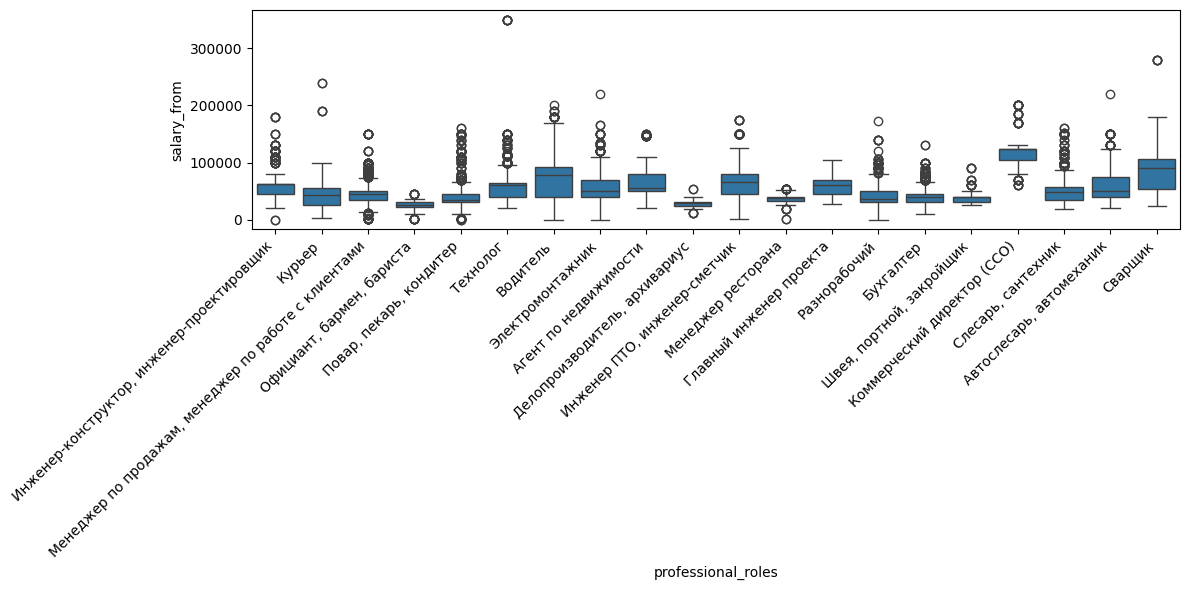

In [20]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    x=columns[1],
    y=columns[0],
    data=dataset[dataset[columns[1]].isin(dataset[columns[1]].unique()[:20])]
)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Поскольку анализируемые выборки являются независимыми, их распределение не является нормальным, а количество сравниваемых групп превышает две, для проверки статистической значимости различий был применён непараметрический критерий Краскала-Уолиса

In [21]:
dataset.groupby(columns[1], observed=False)[columns[0]].apply(list)

,salary_from
professional_roles,
"BI-аналитик, аналитик данных","[71090, 71090, 71090, 50000, 50000, 50000, 710..."
DevOps-инженер,"[237500, 237500, 237500, 237500, 237500, 23750..."
Event-менеджер,"[20000, 20000, 40000, 40000, 40000, 40000, 400..."
PR-менеджер,"[25000, 25000, 25000, 25000, 46666, 46666, 466..."
"SMM-менеджер, контент-менеджер","[42000, 42000, 42000, 42000, 42000, 42000, 400..."
...,...
"Швея, портной, закройщик","[30000, 30000, 30000, 40000, 40000, 40000, 400..."
Экономист,"[45659, 45659, 45659, 45659, 45659, 45659, 500..."
Электромонтажник,"[100000, 100000, 100000, 40000, 40000, 40000, ..."


In [22]:
stats.kruskal(*dataset.groupby(columns[1], observed=False)[columns[0]].apply(list))

KruskalResult(statistic=np.float64(38127.19165284509), pvalue=np.float64(0.0))

* О возможной взаимосвязи признаков:
  
    - Присутствует статистически значимая взаимосвязь между количественным признаком и категориальным

    - Тест Краскела-Уоллис показал статистически значимые различия (p < 0.05), что позволяет отвергнуть нулевую гипотезу об отсутствии различий между группами

* В разрезе основнго признака

    - В среднем самые большие мин.ЗП у DevOps-инженеров

    - В среднем самые маленькие мин.ЗП у психологов

    - В медиане самые большие мин.ЗП у DevOps-инженеров

    - В медиане самые маленькие мин.ЗП у Event-менеджеров

### 16.2 Признаки salary_from и key_skills

**Нулевая гипотеза (H₀): распределения двух независимых выборок идентичны. Уровень значимости полагаем равным 0,05**

Сохраним именна переменных в кортеж columns

In [23]:
columns = ('salary_from', 'key_skills')

Оценим медианные значения данного количественного признака в разрезе данного категориального

In [24]:
dataset.groupby(columns[1], observed=False)[columns[0]].median()

,salary_from
key_skills,
1C: Финансы,41532.0
1С,40000.0
1С: CRM,45000.0
1С: ERP,61775.0
1С: PDM Управление инженерными данными (PLM),60000.0
...,...
Эндокринология,65224.0
Эстетическая косметология,38650.0
Юридическое сопровождение,36824.0


Оценим средние значения данного количественного признака в разрезе данного категориального

In [25]:
dataset.groupby(columns[1], observed=False)[columns[0]].mean()

,salary_from
key_skills,
1C: Финансы,38394.136364
1С,43930.628866
1С: CRM,43750.000000
1С: ERP,70506.235294
1С: PDM Управление инженерными данными (PLM),60000.000000
...,...
Эндокринология,65224.000000
Эстетическая косметология,39100.000000
Юридическое сопровождение,37142.880000


Оценим описательные данного количественного признака в разрезе данного категориального

In [26]:
dataset.groupby(columns[1], observed=False)[columns[0]].describe()

,count,mean,std,min,25%,50%,75%,max
key_skills,,,,,,,,
1C: Финансы,22.0,38394.136364,9162.137535,20000.0,33500.0,41532.0,43826.0,52500.0
1С,194.0,43930.628866,23006.364154,15000.0,30000.0,40000.0,49371.0,237500.0
1С: CRM,4.0,43750.000000,14930.394056,25000.0,36250.0,45000.0,52500.0,60000.0
1С: ERP,68.0,70506.235294,34770.523014,28000.0,45000.0,61775.0,94664.0,180000.0
1С: PDM Управление инженерными данными (PLM),1.0,60000.000000,NaN,60000.0,60000.0,60000.0,60000.0,60000.0
...,...,...,...,...,...,...,...,...
Эндокринология,2.0,65224.000000,0.000000,65224.0,65224.0,65224.0,65224.0,65224.0
Эстетическая косметология,6.0,39100.000000,10017.185233,30000.0,30000.0,38650.0,47300.0,50000.0
Юридическое сопровождение,25.0,37142.880000,10576.592730,20000.0,30000.0,36824.0,45000.0,55000.0


Построим диаграммы "ящик с усами" с помощью метода boxplot(), передав в качестве x - данный категориальный признак, а в качестве y - данный количественный признак

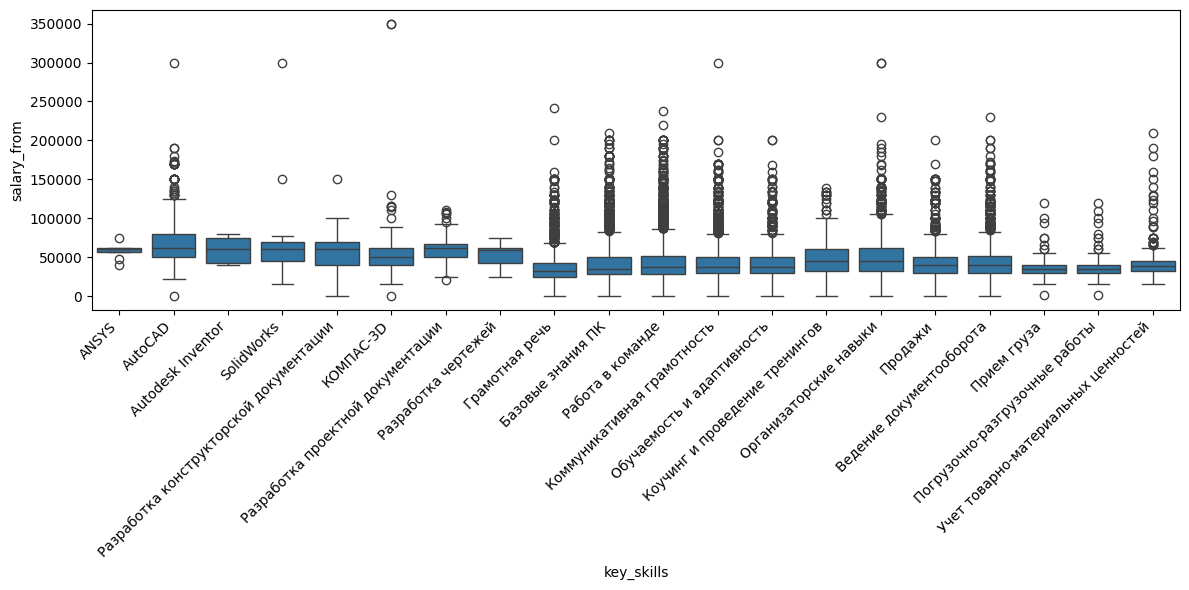

In [27]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    x=columns[1],
    y=columns[0],
    data=dataset[dataset[columns[1]].isin(dataset[columns[1]].unique()[:20])]
)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Поскольку анализируемые выборки являются независимыми, их распределение не является нормальным, а количество сравниваемых групп превышает две, для проверки статистической значимости различий был применён непараметрический критерий Краскала-Уолиса

In [28]:
dataset.groupby(columns[1], observed=False)[columns[0]].apply(list)

,salary_from
key_skills,
1C: Финансы,"[40000, 35000, 43826, 45000, 43826, 25000, 473..."
1С,"[30000, 45395, 50000, 30000, 25000, 36000, 350..."
1С: CRM,"[60000, 50000, 40000, 25000]"
1С: ERP,"[60000, 40000, 80833, 35000, 80833, 40000, 410..."
1С: PDM Управление инженерными данными (PLM),[60000]
...,...
Эндокринология,"[65224, 65224]"
Эстетическая косметология,"[47300, 30000, 47300, 30000, 30000, 50000]"
Юридическое сопровождение,"[36824, 20000, 43447, 30000, 20000, 45000, 200..."


In [29]:
stats.kruskal(*dataset.groupby(columns[1], observed=False)[columns[0]].apply(list))

KruskalResult(statistic=np.float64(16804.285412054327), pvalue=np.float64(0.0))

* О возможной взаимосвязи признаков:
  
    - Присутствует статистически значимая взаимосвязь между количественным признаком и категориальным

    - Тест Краскела-Уоллис показал статистически значимые различия (p < 0.05), что позволяет отвергнуть нулевую гипотезу об отсутствии различий между группами

* В разрезе основнго признака

    - В среднем самые большие мин.ЗП для навыка "Terraform"

    - В среднем самые маленькие мин.ЗП для навыка "взаимодействие с родителями учеников"

    - В медиане самые большие мин.ЗП для навыка "Terraform"

    - В медиане самые маленькие мин.ЗП для навыка "взаимодействие с родителями учеников"

### 16.3 Признаки salary_from и experience

**Нулевая гипотеза (H₀): распределения двух независимых выборок идентичны. Уровень значимости полагаем равным 0,05**

Сохраним именна переменных в кортеж columns

In [30]:
columns = ('salary_from', 'experience')

Оценим медианные значения данного количественного признака в разрезе данного категориального

In [31]:
dataset.groupby(columns[1], observed=False)[columns[0]].median()

,salary_from
experience,
0,32000.0
1-3,43826.0
3-6,60000.0
6-,61226.0


Оценим средние значения данного количественного признака в разрезе данного категориального

In [32]:
dataset.groupby(columns[1], observed=False)[columns[0]].mean()

,salary_from
experience,
0,36338.684155
1-3,50267.604965
3-6,67226.483535
6-,70861.922203


Оценим описательные данного количественного признака в разрезе данного категориального

In [33]:
dataset.groupby(columns[1], observed=False)[columns[0]].describe()

,count,mean,std,min,25%,50%,75%,max
experience,,,,,,,,
0,25731.0,36338.684155,17551.641840,15.0,25000.0,32000.0,43000.0,240000.0
1-3,39313.0,50267.604965,26362.453224,20.0,34259.0,43826.0,60000.0,350000.0
3-6,14607.0,67226.483535,34547.555977,40.0,44673.0,60000.0,82461.0,320000.0
6-,1761.0,70861.922203,41260.303713,35.0,45659.0,61226.0,81000.0,300000.0


Построим диаграммы "ящик с усами" с помощью метода boxplot(), передав в качестве x - данный категориальный признак, а в качестве y - данный количественный признак

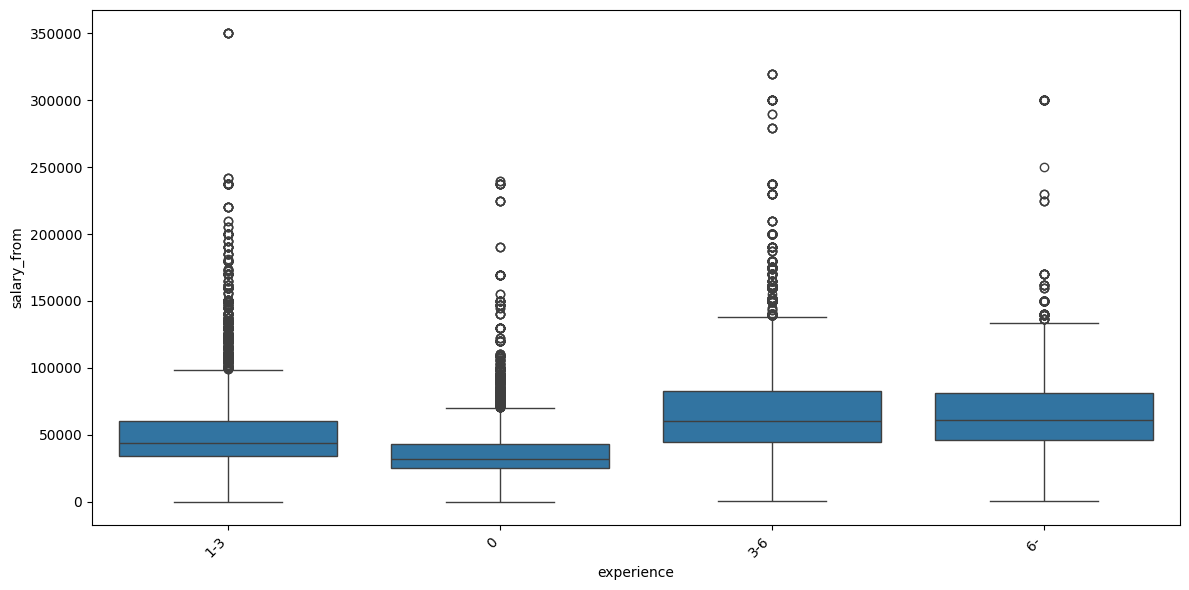

In [34]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    x=columns[1],
    y=columns[0],
    data=dataset
)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Поскольку анализируемые выборки являются независимыми, их распределение не является нормальным, а количество сравниваемых групп превышает две, для проверки статистической значимости различий был применён непараметрический критерий Краскала-Уолиса

In [35]:
dataset.groupby(columns[1], observed=False)[columns[0]].apply(list)

,salary_from
experience,
0,"[60000, 25000, 25000, 25583, 25583, 28000, 280..."
1-3,"[75000, 75000, 75000, 75000, 75000, 75000, 750..."
3-6,"[100000, 100000, 100000, 60702, 60702, 40000, ..."
6-,"[123554, 123554, 123554, 123554, 50000, 50000,..."


In [36]:
stats.kruskal(*dataset.groupby(columns[1], observed=False)[columns[0]].apply(list))

KruskalResult(statistic=np.float64(15794.59889672627), pvalue=np.float64(0.0))

* О возможной взаимосвязи признаков:
  
    - Присутствует статистически значимая взаимосвязь между количественным признаком и категориальным

    - Тест Краскела-Уоллис показал статистически значимые различия (p < 0.05), что позволяет отвергнуть нулевую гипотезу об отсутствии различий между группами

* В разрезе основнго признака

    - В среднем самые большие мин.ЗП у 3-6, 6-

    - В среднем самые маленькие мин.ЗП у 0

    - В медиане самые большие мин.ЗП у 3-6, 6-

    - В медиане самые маленькие мин.ЗП у 0

### 16.4 Признаки salary_from и schedule

**Нулевая гипотеза (H₀): распределения двух независимых выборок идентичны. Уровень значимости полагаем равным 0,05**

Сохраним именна переменных в кортеж columns

In [37]:
columns = ('salary_from', 'schedule')

Оценим медианные значения данного количественного признака в разрезе данного категориального

In [38]:
dataset.groupby(columns[1], observed=False)[columns[0]].median()

,salary_from
schedule,
flexible,33000.0
full_day,41064.0
labor,92164.0
remote,41000.0
shift,31000.0


Оценим средние значения данного количественного признака в разрезе данного категориального

In [39]:
dataset.groupby(columns[1], observed=False)[columns[0]].mean()

,salary_from
schedule,
flexible,41980.653905
full_day,47355.413226
labor,93778.625084
remote,52603.896326
shift,34568.523756


Оценим описательные данного количественного признака в разрезе данного категориального

In [40]:
dataset.groupby(columns[1], observed=False)[columns[0]].describe()

,count,mean,std,min,25%,50%,75%,max
schedule,,,,,,,,
flexible,3265.0,41980.653905,27333.823011,3000.0,25585.0,33000.0,50584.0,240000.0
full_day,60168.0,47355.413226,24451.921327,15.0,30000.0,41064.0,58704.0,320000.0
labor,5948.0,93778.625084,34937.509442,1000.0,68000.0,92164.0,115000.0,350000.0
remote,3212.0,52603.896326,35274.633988,500.0,29367.0,41000.0,62073.0,250000.0
shift,8819.0,34568.523756,14140.951648,27.0,25000.0,31000.0,40000.0,200000.0


Построим диаграммы "ящик с усами" с помощью метода boxplot(), передав в качестве x - данный категориальный признак, а в качестве y - данный количественный признак

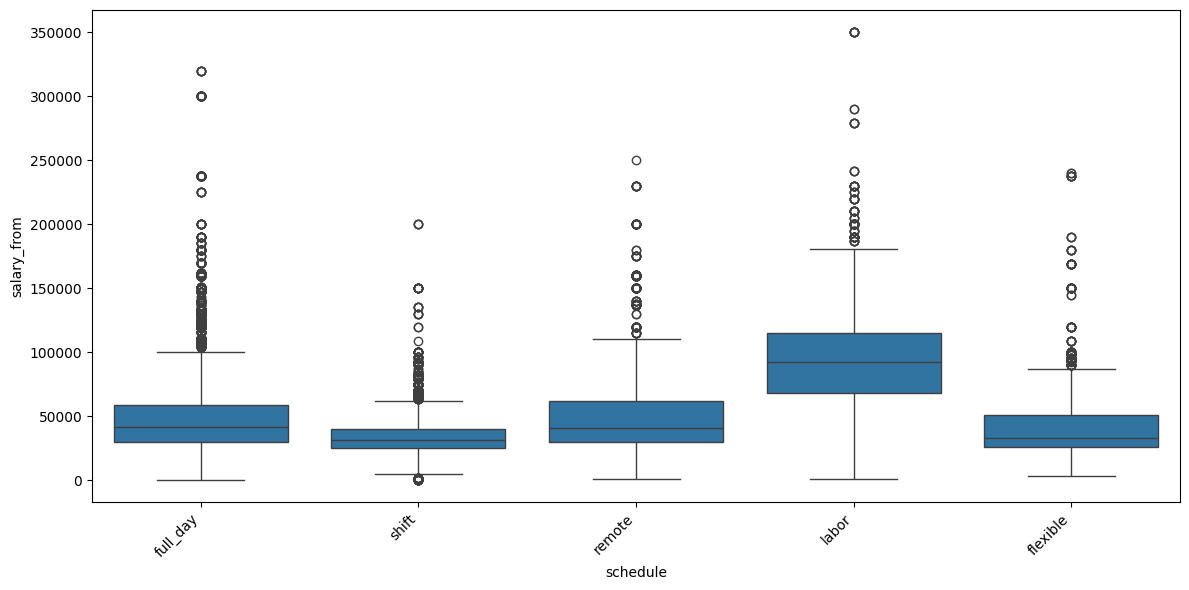

In [41]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    x=columns[1],
    y=columns[0],
    data=dataset
)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Поскольку анализируемые выборки являются независимыми, их распределение не является нормальным, а количество сравниваемых групп превышает две, для проверки статистической значимости различий был применён непараметрический критерий Краскала-Уолиса

In [42]:
dataset.groupby(columns[1], observed=False)[columns[0]].apply(list)

,salary_from
schedule,
flexible,"[78598, 78598, 24000, 24000, 24000, 24000, 350..."
full_day,"[75000, 75000, 75000, 75000, 75000, 75000, 750..."
labor,"[100000, 100000, 100000, 60702, 60702, 160000,..."
remote,"[25000, 25000, 37000, 100000, 100000, 100000, ..."
shift,"[60000, 25583, 25583, 20000, 20000, 20000, 200..."


In [43]:
stats.kruskal(*dataset.groupby(columns[1], observed=False)[columns[0]].apply(list))

KruskalResult(statistic=np.float64(13736.841847881398), pvalue=np.float64(0.0))

* О возможной взаимосвязи признаков:
  
    - Присутствует статистически значимая взаимосвязь между количественным признаком и категориальным

    - Тест Краскела-Уоллис показал статистически значимые различия (p < 0.05), что позволяет отвергнуть нулевую гипотезу об отсутствии различий между группами

* В разрезе основнго признака

    - В среднем самые большие мин.ЗП у remote и labor

    - В среднем самые маленькие мин.ЗП у shift

    - В медиане самые большие мин.ЗП у labor

    - В медиане самые маленькие мин.ЗП у shift

    - В целом сотрудникам с графиком labor готовы предложить значительно больше, чем по другим графикам

### 16.5 Признаки salary_from и employment

**Нулевая гипотеза (H₀): распределения двух независимых выборок идентичны. Уровень значимости полагаем равным 0,05**

Сохраним именна переменных в кортеж columns

In [44]:
columns = ('salary_from', 'employment')

Оценим медианные значения данного количественного признака в разрезе данного категориального

In [45]:
dataset.groupby(columns[1], observed=False)[columns[0]].median()

,salary_from
employment,
full,42000.0
part,28000.0
probation,47300.0
project,50000.0


Оценим средние значения данного количественного признака в разрезе данного категориального

In [46]:
dataset.groupby(columns[1], observed=False)[columns[0]].mean()

,salary_from
employment,
full,50354.382460
part,32769.084580
probation,48039.852090
project,53893.795918


Оценим описательные данного количественного признака в разрезе данного категориального

In [47]:
dataset.groupby(columns[1], observed=False)[columns[0]].describe()

,count,mean,std,min,25%,50%,75%,max
employment,,,,,,,,
full,75885.0,50354.382460,28393.616154,20.0,30000.0,42000.0,60000.0,350000.0
part,4611.0,32769.084580,22119.458871,15.0,20000.0,28000.0,41000.0,240000.0
probation,622.0,48039.852090,29671.583513,10000.0,30000.0,47300.0,53850.0,237500.0
project,294.0,53893.795918,27235.962495,400.0,35000.0,50000.0,72300.0,120000.0


Построим диаграммы "ящик с усами" с помощью метода boxplot(), передав в качестве x - данный категориальный признак, а в качестве y - данный количественный признак

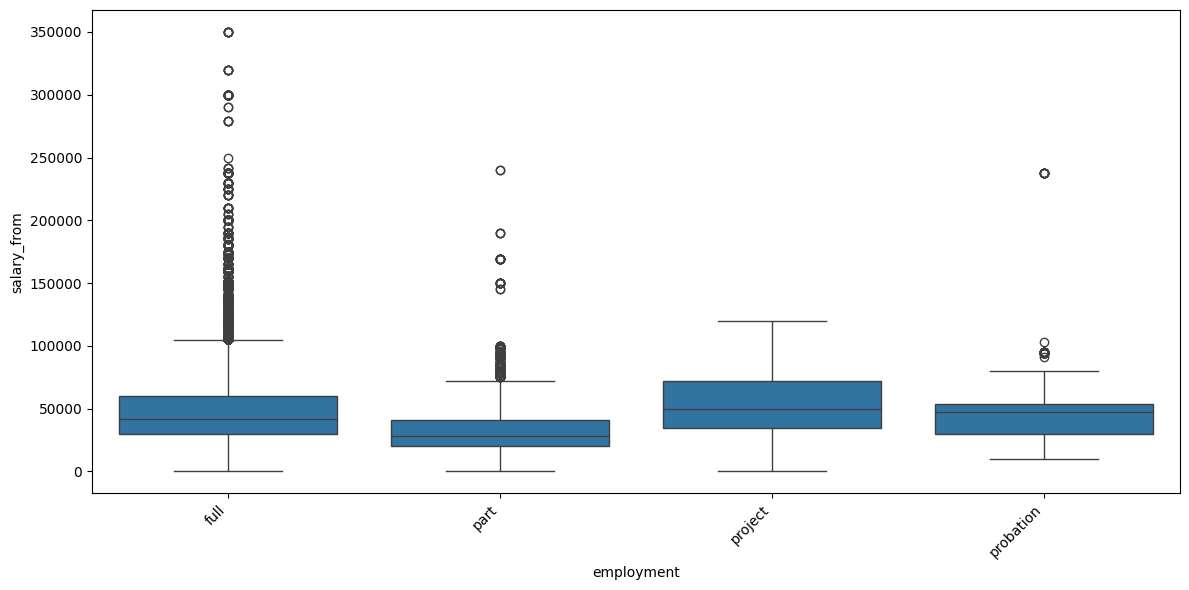

In [48]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    x=columns[1],
    y=columns[0],
    data=dataset
)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Поскольку анализируемые выборки являются независимыми, их распределение не является нормальным, а количество сравниваемых групп превышает две, для проверки статистической значимости различий был применён непараметрический критерий Краскала-Уолиса

In [49]:
dataset.groupby(columns[1], observed=False)[columns[0]].apply(list)

,salary_from
employment,
full,"[75000, 75000, 75000, 75000, 75000, 75000, 750..."
part,"[60000, 25000, 25000, 20000, 20000, 20000, 200..."
probation,"[45395, 45395, 45395, 45395, 45395, 25000, 250..."
project,"[30500, 33000, 33000, 33000, 35000, 35000, 350..."


In [50]:
stats.kruskal(*dataset.groupby(columns[1], observed=False)[columns[0]].apply(list))

KruskalResult(statistic=np.float64(2872.515573493091), pvalue=np.float64(0.0))

* О возможной взаимосвязи признаков:
  
    - Присутствует статистически значимая взаимосвязь между количественным признаком и категориальным

    - Тест Краскела-Уоллис показал статистически значимые различия (p < 0.05), что позволяет отвергнуть нулевую гипотезу об отсутствии различий между группами

* В разрезе основнго признака

    - В среднем самые большие мин.ЗП у project и full

    - В среднем самые маленькие мин.ЗП у part

    - В медиане самые большие мин.ЗП у project и probation

    - В медиане самые маленькие мин.ЗП у part

### 16.6 Признаки salary_from и accept_handicapped

**Нулевая гипотеза (H₀): распределения двух независимых выборок идентичны. Уровень значимости полагаем равным 0,05**

Сохраним именна переменных в кортеж columns

In [51]:
columns = ('salary_from', 'accept_handicapped')

Оценим медианные значения данного количественного признака в разрезе данного категориального

In [52]:
dataset.groupby(columns[1], observed=False)[columns[0]].median()

,salary_from
accept_handicapped,
0,41000.0
1,36824.0


Оценим средние значения данного количественного признака в разрезе данного категориального

In [53]:
dataset.groupby(columns[1], observed=False)[columns[0]].mean()

,salary_from
accept_handicapped,
0,49447.500138
1,44034.660537


Оценим описательные данного количественного признака в разрезе данного категориального

In [54]:
dataset.groupby(columns[1], observed=False)[columns[0]].describe()

,count,mean,std,min,25%,50%,75%,max
accept_handicapped,,,,,,,,
0,79998.0,49447.500138,28359.564077,15.0,30000.0,41000.0,60000.0,350000.0
1,1414.0,44034.660537,28763.001843,1400.0,28729.0,36824.0,54464.0,240000.0


Построим диаграммы "ящик с усами" с помощью метода boxplot(), передав в качестве x - данный категориальный признак, а в качестве y - данный количественный признак

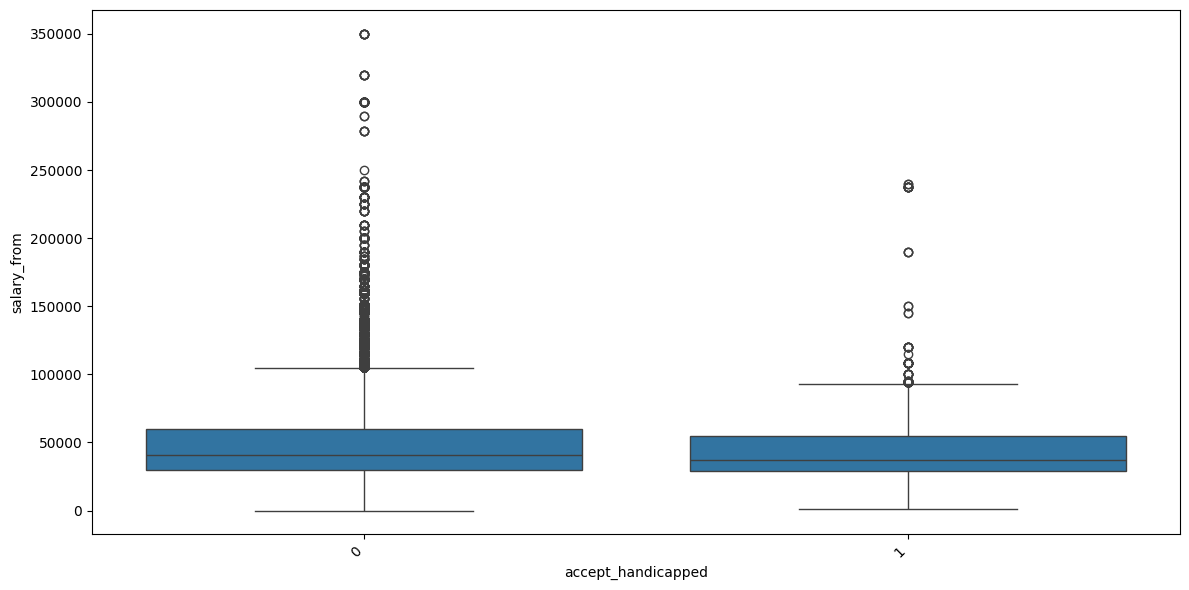

In [55]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    x=columns[1],
    y=columns[0],
    data=dataset
)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Поскольку анализируемые выборки являются независимыми, их распределение не является нормальным, а количество сравниваемых групп не превышает две, для проверки статистической значимости различий был применён непараметрический критерий Манна-Уитни

In [56]:
dataset.groupby(columns[1], observed=False)[columns[0]].apply(list)

,salary_from
accept_handicapped,
0,"[75000, 75000, 75000, 75000, 75000, 75000, 750..."
1,"[25000, 25000, 24000, 24000, 24000, 24000, 600..."


In [57]:
stats.mannwhitneyu(*dataset.groupby(columns[1], observed=False)[columns[0]].apply(list))

MannwhitneyuResult(statistic=np.float64(64900548.0), pvalue=np.float64(1.545798490898628e-21))

* О возможной взаимосвязи признаков:
  
    - Присутствует статистически значимая взаимосвязь между количественным признаком и категориальным

    - Тест Манна-Уитни показал статистически значимые различия (p < 0.05), что позволяет отвергнуть нулевую гипотезу об отсутствии различий между группами

* В разрезе основнго признака

    - В среднем самые большие мин.ЗП у соискателей без инвалидности

    - В среднем самые маленькие мин.ЗП у соискателей с инвалидностью

    - В медиане самые большие мин.ЗП у соискателей без инвалидности

    - В медиане самые маленькие мин.ЗП у соискателей с инвалидностью

    - В целом зарплаты у соискателей без инвалидности на несколько тысяч больше, чем у соискателей с инвалидностью

### 16.7 Признаки salary_from и city

**Нулевая гипотеза (H₀): распределения двух независимых выборок идентичны. Уровень значимости полагаем равным 0,05**

Сохраним именна переменных в кортеж columns

In [58]:
columns = ('salary_from', 'city')

Оценим медианные значения данного количественного признака в разрезе данного категориального

In [59]:
dataset.groupby(columns[1], observed=False)[columns[0]].median()

,salary_from
city,
Александровское (Томская область),46510.0
Асино,30000.0
Бакчар,62612.0
Батурино,92164.0
Белый Яр,45200.0
Богашёво,55000.0
Зональная Станция,40000.0
Зоркальцево,50000.0
Зырянское,23000.0


Оценим средние значения данного количественного признака в разрезе данного категориального

In [60]:
dataset.groupby(columns[1], observed=False)[columns[0]].mean()

,salary_from
city,
Александровское (Томская область),54933.776923
Асино,40264.626263
Бакчар,65275.329268
Батурино,83742.769231
Белый Яр,61569.792683
Богашёво,60914.312500
Зональная Станция,46509.789474
Зоркальцево,59743.583333
Зырянское,36201.838983


Оценим описательные данного количественного признака в разрезе данного категориального

In [61]:
dataset.groupby(columns[1], observed=False)[columns[0]].describe()

,count,mean,std,min,25%,50%,75%,max
city,,,,,,,,
Александровское (Томская область),130.0,54933.776923,26327.352161,4800.0,35000.0,46510.0,70000.00,122156.0
Асино,396.0,40264.626263,23898.890949,15000.0,25000.0,30000.0,45395.00,130000.0
Бакчар,82.0,65275.329268,27292.835759,15000.0,45200.0,62612.0,82865.25,123000.0
Батурино,13.0,83742.769231,39168.166713,40000.0,40000.0,92164.0,130000.00,130000.0
Белый Яр,82.0,61569.792683,31428.470757,25000.0,31250.0,45200.0,92164.00,130000.0
Богашёво,64.0,60914.312500,24866.893090,25000.0,42650.0,55000.0,92164.00,92164.0
Зональная Станция,152.0,46509.789474,23361.336376,15000.0,32000.0,40000.0,47051.00,130000.0
Зоркальцево,48.0,59743.583333,34354.781138,15000.0,32107.0,50000.0,92164.00,130000.0
Зырянское,118.0,36201.838983,22691.929561,15000.0,23000.0,23000.0,42760.00,92164.0


Построим диаграммы "ящик с усами" с помощью метода boxplot(), передав в качестве x - данный категориальный признак, а в качестве y - данный количественный признак

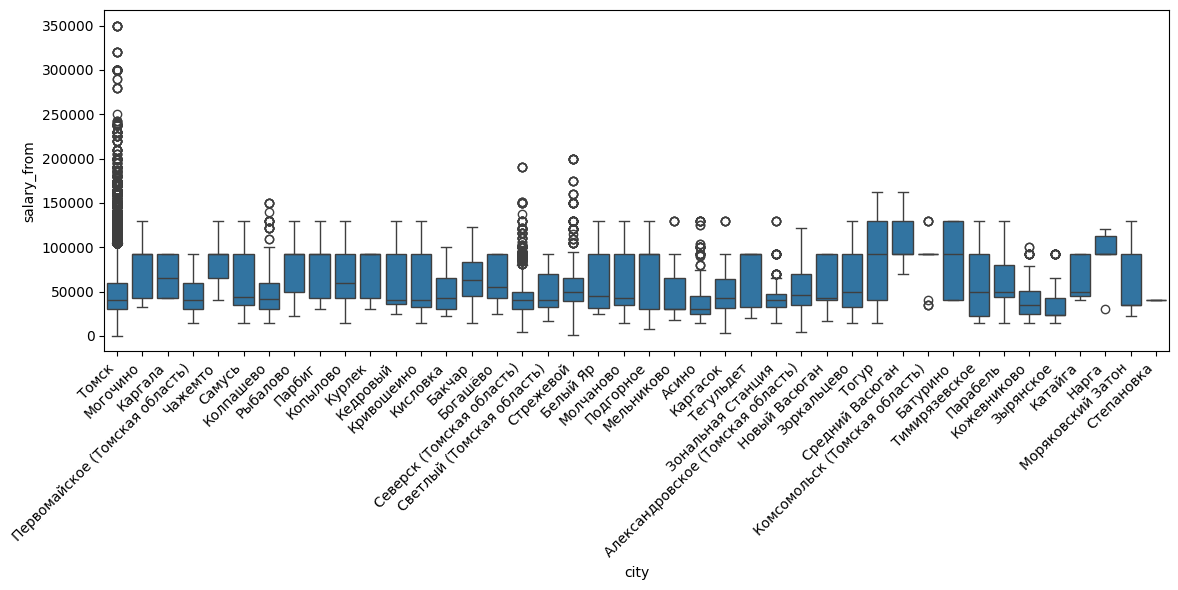

In [62]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    x=columns[1],
    y=columns[0],
    data=dataset
)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Поскольку анализируемые выборки являются независимыми, их распределение не является нормальным, а количество сравниваемых групп превышает две, для проверки статистической значимости различий был применён непараметрический критерий Краскала-Уолиса

In [63]:
dataset.groupby(columns[1], observed=False)[columns[0]].apply(list)

,salary_from
city,
Александровское (Томская область),"[70000, 70000, 70000, 70000, 70000, 70000, 400..."
Асино,"[45000, 45000, 45000, 45000, 45000, 45000, 450..."
Бакчар,"[45200, 45200, 45200, 45200, 45200, 45200, 452..."
Батурино,"[130000, 130000, 130000, 130000, 92164, 92164,..."
Белый Яр,"[92164, 92164, 30000, 30000, 30000, 30000, 300..."
Богашёво,"[45200, 45200, 45200, 45200, 45200, 45200, 452..."
Зональная Станция,"[42395, 42395, 42395, 42395, 46968, 46968, 469..."
Зоркальцево,"[15000, 15000, 15000, 130000, 130000, 130000, ..."
Зырянское,"[15000, 15000, 15000, 92164, 92164, 35000, 350..."


In [64]:
stats.kruskal(*dataset.groupby(columns[1], observed=False)[columns[0]].apply(list))

KruskalResult(statistic=np.float64(807.1727060825792), pvalue=np.float64(6.74512589043286e-143))

* О возможной взаимосвязи признаков:
  
    - Присутствует статистически значимая взаимосвязь между количественным признаком и категориальным

    - Тест Краскала-Уолиса показал статистически значимые различия (p < 0.05), что позволяет отвергнуть нулевую гипотезу об отсутствии различий между группами

* В разрезе основнго признака

    - В среднем самые большие мин.ЗП у вакансий в Среднем Васюгане

    - В среднем самые маленькие мин.ЗП у вакансий в Зырянском

    - В медиане самые большие мин.ЗП у вакансий Батурино, Чажемто, Парбиг,Подгорное, Рыбалово, Средний Васюган, Курлек, Могочино, Нарга, Комсомольск (Томская область), Тогур, Тегульдет

    - В медиане самые маленькие мин.ЗП у вакансий в Зырянском

### 16.8 Признаки salary_from и field_of_activity

**Нулевая гипотеза (H₀): распределения двух независимых выборок идентичны. Уровень значимости полагаем равным 0,05**

Сохраним именна переменных в кортеж columns

In [65]:
columns = ('salary_from', 'field_of_activity')

Оценим медианные значения данного количественного признака в разрезе данного категориального

In [66]:
dataset.groupby(columns[1], observed=False)[columns[0]].median()

,salary_from
field_of_activity,
IT и технологии,80000.0
Аналитика и исследования,64038.0
Бытовые услуги,25000.0
Другие сферы,45060.0
Инженерия и строительство,60000.0
Маркетинг и реклама,39775.0
Медицина и фармацевтика,50000.0
Образование и наука,28729.0
Производство и технические специальности,53850.0


Оценим средние значения данного количественного признака в разрезе данного категориального

In [67]:
dataset.groupby(columns[1], observed=False)[columns[0]].mean()

,salary_from
field_of_activity,
IT и технологии,78218.838011
Аналитика и исследования,63425.930535
Бытовые услуги,28293.957661
Другие сферы,44207.693919
Инженерия и строительство,63849.076948
Маркетинг и реклама,38812.898946
Медицина и фармацевтика,51868.929815
Образование и наука,31983.526240
Производство и технические специальности,59557.386011


Оценим описательные данного количественного признака в разрезе данного категориального

In [68]:
dataset.groupby(columns[1], observed=False)[columns[0]].describe()

,count,mean,std,min,25%,50%,75%,max
field_of_activity,,,,,,,,
IT и технологии,4988.0,78218.838011,42961.343582,600.0,50000.0,80000.0,94664.0,320000.0
Аналитика и исследования,691.0,63425.930535,26845.176295,500.0,60000.0,64038.0,64038.0,300000.0
Бытовые услуги,992.0,28293.957661,14641.527692,140.0,20000.0,25000.0,35000.0,120000.0
Другие сферы,7302.0,44207.693919,22557.039858,35.0,30000.0,45060.0,50000.0,290000.0
Инженерия и строительство,9292.0,63849.076948,28201.435110,40.0,45000.0,60000.0,74712.0,220000.0
Маркетинг и реклама,1613.0,38812.898946,17610.629092,5000.0,30000.0,39775.0,42000.0,150000.0
Медицина и фармацевтика,3733.0,51868.929815,23418.017441,30.0,32476.0,50000.0,65224.0,200000.0
Образование и наука,2096.0,31983.526240,14937.574126,20.0,23222.0,28729.0,40000.0,140000.0
Производство и технические специальности,5347.0,59557.386011,30236.340303,35.0,40000.0,53850.0,70000.0,350000.0


Построим диаграммы "ящик с усами" с помощью метода boxplot(), передав в качестве x - данный категориальный признак, а в качестве y - данный количественный признак

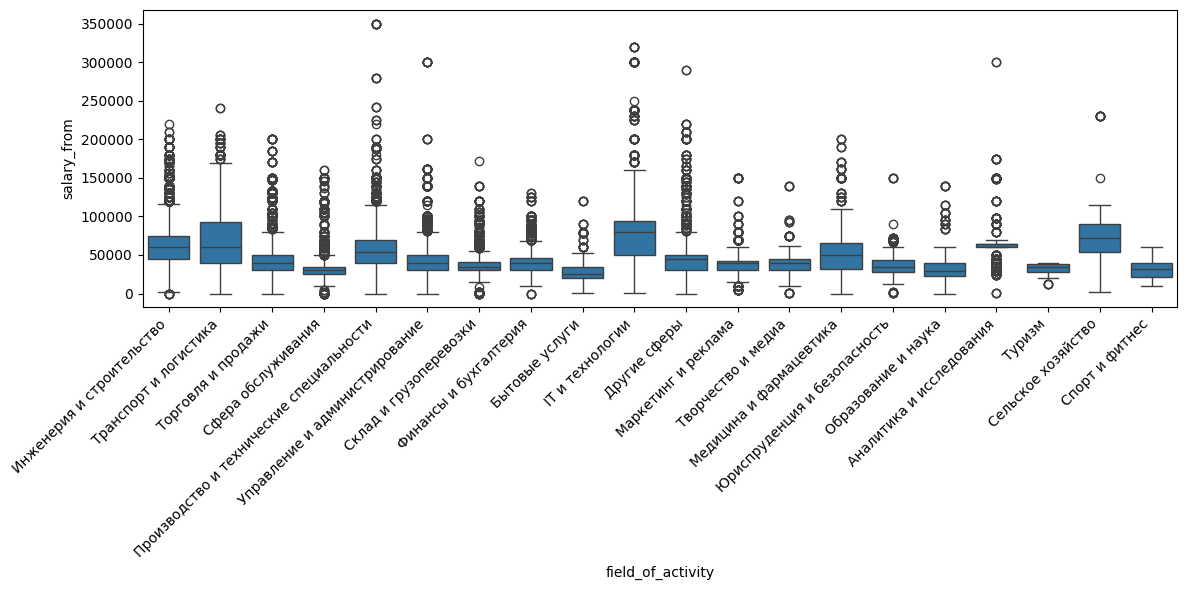

In [69]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    x=columns[1],
    y=columns[0],
    data=dataset
)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Поскольку анализируемые выборки являются независимыми, их распределение не является нормальным, а количество сравниваемых групп превышает две, для проверки статистической значимости различий был применён непараметрический критерий Краскала-Уолиса

In [70]:
dataset.groupby(columns[1], observed=False)[columns[0]].apply(list)

,salary_from
field_of_activity,
IT и технологии,"[70000, 70000, 70000, 70000, 20000, 20000, 200..."
Аналитика и исследования,"[64038, 64038, 64038, 64038, 64038, 64038, 640..."
Бытовые услуги,"[30000, 19863, 8000, 8000, 8000, 8000, 8000, 8..."
Другие сферы,"[23000, 23000, 23000, 50000, 50000, 50000, 500..."
Инженерия и строительство,"[75000, 75000, 75000, 75000, 75000, 75000, 750..."
Маркетинг и реклама,"[40000, 40000, 40000, 40000, 42000, 42000, 420..."
Медицина и фармацевтика,"[30000, 30000, 30000, 30000, 32476, 32476, 324..."
Образование и наука,"[8000, 8000, 8000, 8000, 8000, 24000, 24000, 2..."
Производство и технические специальности,"[60000, 60000, 60000, 32000, 32000, 32000, 400..."


In [71]:
stats.kruskal(*dataset.groupby(columns[1], observed=False)[columns[0]].apply(list))

KruskalResult(statistic=np.float64(20611.52570070318), pvalue=np.float64(0.0))

* О возможной взаимосвязи признаков:
  
    - Присутствует статистически значимая взаимосвязь между количественным признаком и категориальным

    - Тест Краскала-Уолиса показал статистически значимые различия (p < 0.05), что позволяет отвергнуть нулевую гипотезу об отсутствии различий между группами

* В разрезе основнго признака

    - В среднем самые большие мин.ЗП в сфере "IT и технологии"

    - В среднем самые маленькие мин.ЗП в сфере "Бытовые услуги"

    - В медиане самые большие мин.ЗП в сфере "IT и технологии"

    - В медиане самые маленькие мин.ЗП в сфере "Бытовые услуги"

### 16.9 Признаки salary_to и professional_roles

**Нулевая гипотеза (H₀): распределения двух независимых выборок идентичны. Уровень значимости полагаем равным 0,05**

Сохраним именна переменных в кортеж columns

In [72]:
columns = ('salary_to', 'professional_roles')

Оценим медианные значения данного количественного признака в разрезе данного категориального

In [73]:
dataset.groupby(columns[1], observed=False)[columns[0]].median()

,salary_to
professional_roles,
"BI-аналитик, аналитик данных",108000.0
DevOps-инженер,300000.0
Event-менеджер,45000.0
PR-менеджер,54761.0
"SMM-менеджер, контент-менеджер",43531.0
...,...
"Швея, портной, закройщик",59875.0
Экономист,45659.0
Электромонтажник,73159.0


Оценим средние значения данного количественного признака в разрезе данного категориального

In [74]:
dataset.groupby(columns[1], observed=False)[columns[0]].mean()

,salary_to
professional_roles,
"BI-аналитик, аналитик данных",108000.000000
DevOps-инженер,300000.000000
Event-менеджер,45869.406250
PR-менеджер,54761.426966
"SMM-менеджер, контент-менеджер",44653.545961
...,...
"Швея, портной, закройщик",60005.478873
Экономист,48453.318221
Электромонтажник,76382.013730


Оценим описательные данного количественного признака в разрезе данного категориального

In [75]:
dataset.groupby(columns[1], observed=False)[columns[0]].describe()

,count,mean,std,min,25%,50%,75%,max
professional_roles,,,,,,,,
"BI-аналитик, аналитик данных",35.0,108000.000000,43261.176727,22000.0,108000.0,108000.0,108000.0,200000.0
DevOps-инженер,79.0,300000.000000,0.000000,300000.0,300000.0,300000.0,300000.0,300000.0
Event-менеджер,32.0,45869.406250,6678.344149,25000.0,45000.0,45000.0,45869.0,55000.0
PR-менеджер,89.0,54761.426966,10027.019784,30000.0,50000.0,54761.0,54761.0,70000.0
"SMM-менеджер, контент-менеджер",359.0,44653.545961,15038.124110,10000.0,40000.0,43531.0,47500.0,100000.0
...,...,...,...,...,...,...,...,...
"Швея, портной, закройщик",142.0,60005.478873,16289.430484,30000.0,50000.0,59875.0,70000.0,100000.0
Экономист,1147.0,48453.318221,18359.954895,80.0,43826.0,45659.0,50000.0,155000.0
Электромонтажник,874.0,76382.013730,30786.685556,15000.0,55300.0,73159.0,98000.0,240000.0


Построим диаграммы "ящик с усами" с помощью метода boxplot(), передав в качестве x - данный категориальный признак, а в качестве y - данный количественный признак

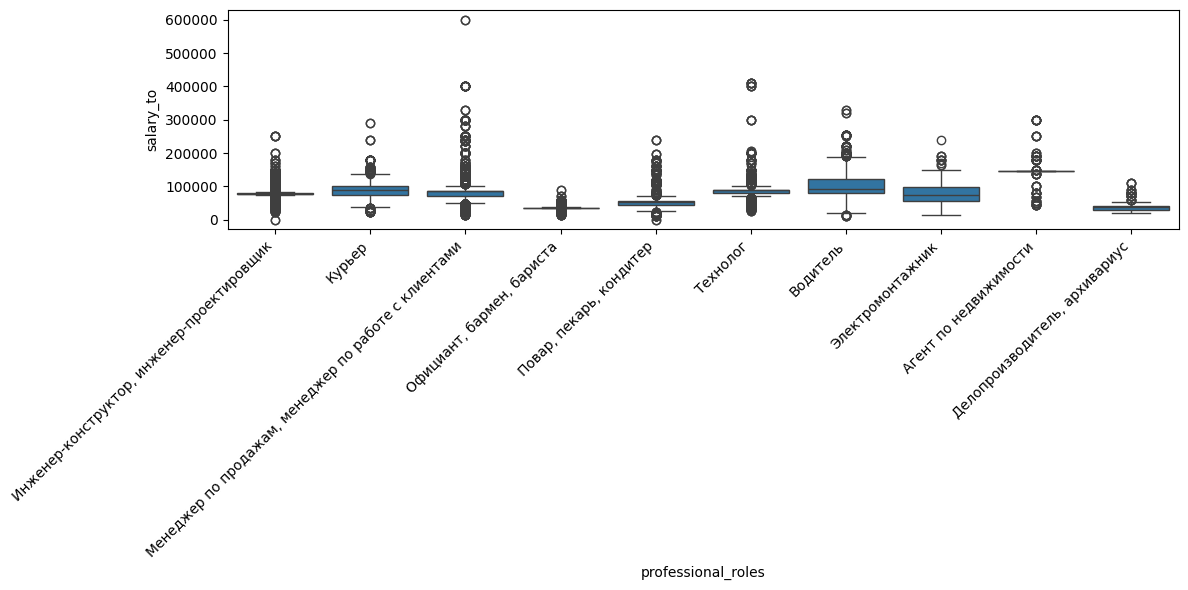

In [76]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    x=columns[1],
    y=columns[0],
    data=dataset[dataset[columns[1]].isin(dataset[columns[1]].unique()[:10])]
)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Поскольку анализируемые выборки являются независимыми, их распределение не является нормальным, а количество сравниваемых групп превышает две, для проверки статистической значимости различий был применён непараметрический критерий Краскала-Уолиса

In [77]:
dataset.groupby(columns[1], observed=False)[columns[0]].apply(list)

,salary_to
professional_roles,
"BI-аналитик, аналитик данных","[108000, 108000, 108000, 100000, 100000, 10000..."
DevOps-инженер,"[300000, 300000, 300000, 300000, 300000, 30000..."
Event-менеджер,"[25000, 25000, 55000, 55000, 55000, 55000, 550..."
PR-менеджер,"[45000, 45000, 45000, 45000, 54761, 54761, 547..."
"SMM-менеджер, контент-менеджер","[54000, 54000, 54000, 54000, 54000, 54000, 700..."
...,...
"Швея, портной, закройщик","[45000, 35000, 35000, 60000, 60000, 60000, 600..."
Экономист,"[50000, 50000, 50000, 50000, 50000, 50000, 500..."
Электромонтажник,"[150000, 150000, 150000, 55000, 55000, 55000, ..."


In [78]:
stats.kruskal(*dataset.groupby(columns[1], observed=False)[columns[0]].apply(list))

KruskalResult(statistic=np.float64(46305.53794091878), pvalue=np.float64(0.0))

* О возможной взаимосвязи признаков:
  
    - Присутствует статистически значимая взаимосвязь между количественным признаком и категориальным

    - Тест Краскела-Уоллис показал статистически значимые различия (p < 0.05), что позволяет отвергнуть нулевую гипотезу об отсутствии различий между группами
  
* В разрезе основнго признака

    - В среднем самые большие макс.ЗП у DevOps-инженеров

    - В среднем самые маленькие макс.ЗП у воспитательниц и нянь

    - В медиане самые большие макс.ЗП у DevOps-инженеров

    - В медиане самые маленькие макс.ЗП у дворников

### 16.10 Признаки salary_to и key_skills

**Нулевая гипотеза (H₀): распределения двух независимых выборок идентичны. Уровень значимости полагаем равным 0,05**

Сохраним именна переменных в кортеж columns

In [79]:
columns = ('salary_to', 'key_skills')

Оценим медианные значения данного количественного признака в разрезе данного категориального

In [80]:
dataset.groupby(columns[1], observed=False)[columns[0]].median()

,salary_to
key_skills,
1C: Финансы,45659.0
1С,50000.0
1С: CRM,69217.5
1С: ERP,92771.0
1С: PDM Управление инженерными данными (PLM),61829.0
...,...
Эндокринология,82461.0
Эстетическая косметология,61829.0
Юридическое сопровождение,48368.0


Оценим средние значения данного количественного признака в разрезе данного категориального

In [81]:
dataset.groupby(columns[1], observed=False)[columns[0]].mean()

,salary_to
key_skills,
1C: Финансы,48193.045455
1С,65267.824742
1С: CRM,124608.750000
1С: ERP,105962.779412
1С: PDM Управление инженерными данными (PLM),61829.000000
...,...
Эндокринология,82461.000000
Эстетическая косметология,59247.833333
Юридическое сопровождение,49550.360000


Оценим описательные данного количественного признака в разрезе данного категориального

In [82]:
dataset.groupby(columns[1], observed=False)[columns[0]].describe()

,count,mean,std,min,25%,50%,75%,max
key_skills,,,,,,,,
1C: Финансы,22.0,48193.045455,13346.241627,25000.0,45164.75,45659.0,50000.00,84520.0
1С,194.0,65267.824742,41765.103401,26000.0,41298.00,50000.0,73500.00,300000.0
1С: CRM,4.0,124608.750000,117214.603451,60000.0,60526.50,69217.5,133299.75,300000.0
1С: ERP,68.0,105962.779412,58476.561325,40000.0,50000.00,92771.0,159807.00,300000.0
1С: PDM Управление инженерными данными (PLM),1.0,61829.000000,NaN,61829.0,61829.00,61829.0,61829.00,61829.0
...,...,...,...,...,...,...,...,...
Эндокринология,2.0,82461.000000,0.000000,82461.0,82461.00,82461.0,82461.00,82461.0
Эстетическая косметология,6.0,59247.833333,7831.234830,50000.0,52957.25,61829.0,61829.00,70000.0
Юридическое сопровождение,25.0,49550.360000,15892.684666,20000.0,45000.00,48368.0,55000.00,100000.0


Построим диаграммы "ящик с усами" с помощью метода boxplot(), передав в качестве x - данный категориальный признак, а в качестве y - данный количественный признак

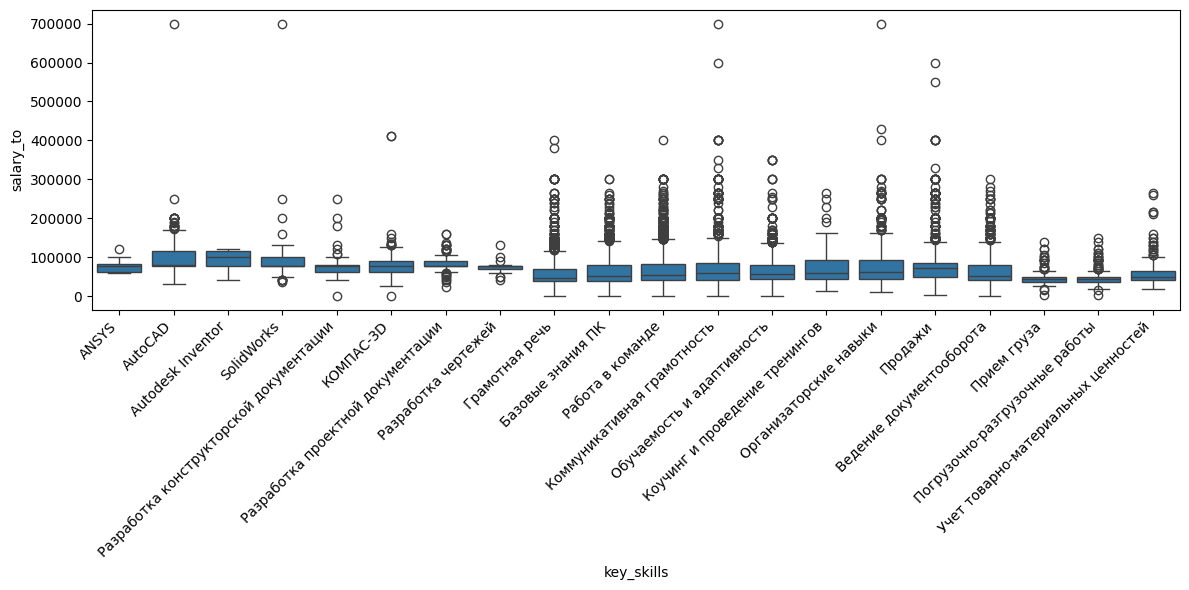

In [83]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    x=columns[1],
    y=columns[0],
    data=dataset[dataset[columns[1]].isin(dataset[columns[1]].unique()[:20])]
)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Поскольку анализируемые выборки являются независимыми, их распределение не является нормальным, а количество сравниваемых групп превышает две, для проверки статистической значимости различий был применён непараметрический критерий Краскала-Уолиса

In [84]:
dataset.groupby(columns[1], observed=False)[columns[0]].apply(list)

,salary_to
key_skills,
1C: Финансы,"[50000, 84520, 45659, 45000, 45659, 40000, 618..."
1С,"[39274, 84520, 50000, 46968, 40000, 50000, 470..."
1С: CRM,"[300000, 77733, 60000, 60702]"
1С: ERP,"[300000, 60000, 110000, 47000, 110000, 45000, ..."
1С: PDM Управление инженерными данными (PLM),[61829]
...,...
Эндокринология,"[82461, 82461]"
Эстетическая косметология,"[61829, 50000, 61829, 70000, 50000, 61829]"
Юридическое сопровождение,"[48368, 20000, 60000, 45000, 48368, 75000, 250..."


In [85]:
stats.kruskal(*dataset.groupby(columns[1], observed=False)[columns[0]].apply(list))

KruskalResult(statistic=np.float64(17098.792016129984), pvalue=np.float64(0.0))

* О возможной взаимосвязи признаков:
  
    - Присутствует статистически значимая взаимосвязь между количественным признаком и категориальным

    - Тест Краскела-Уоллис показал статистически значимые различия (p < 0.05), что позволяет отвергнуть нулевую гипотезу об отсутствии различий между группами

* В разрезе основнго признака

    - В среднем самые большие макс.ЗП для Realm DB, Работа с банковскими гарантиями
    
    - В среднем самые маленькие макс.ЗП для актуарной деятельности

    - В медиане самые большие макс.ЗП для Работа с банковскими гарантиями,
    Realm DB, Terraform

    - В медиане самые маленькие макс.ЗП для актуарной деятельность

### 16.11 Признаки salary_to и experience

**Нулевая гипотеза (H₀): распределения двух независимых выборок идентичны. Уровень значимости полагаем равным 0,05**

Сохраним именна переменных в кортеж columns

In [86]:
columns = ('salary_to', 'experience')

Оценим медианные значения данного количественного признака в разрезе данного категориального

In [87]:
dataset.groupby(columns[1], observed=False)[columns[0]].median()

,salary_to
experience,
0,47300.0
1-3,61829.0
3-6,80000.0
6-,84520.0


Оценим средние значения данного количественного признака в разрезе данного категориального

In [88]:
dataset.groupby(columns[1], observed=False)[columns[0]].mean()

,salary_to
experience,
0,57354.414986
1-3,75309.428408
3-6,94715.410557
6-,99520.385576


Оценим описательные данного количественного признака в разрезе данного категориального

In [89]:
dataset.groupby(columns[1], observed=False)[columns[0]].describe()

,count,mean,std,min,25%,50%,75%,max
experience,,,,,,,,
0,25731.0,57354.414986,32115.370384,25.0,36793.0,47300.0,70000.0,600000.0
1-3,39313.0,75309.428408,41906.188444,25.0,46968.0,61829.0,90000.0,600000.0
3-6,14607.0,94715.410557,53131.204951,69.0,60000.0,80000.0,120000.0,700000.0
6-,1761.0,99520.385576,62018.165513,80.0,61829.0,84520.0,120000.0,430000.0


Построим диаграммы "ящик с усами" с помощью метода boxplot(), передав в качестве x - данный категориальный признак, а в качестве y - данный количественный признак

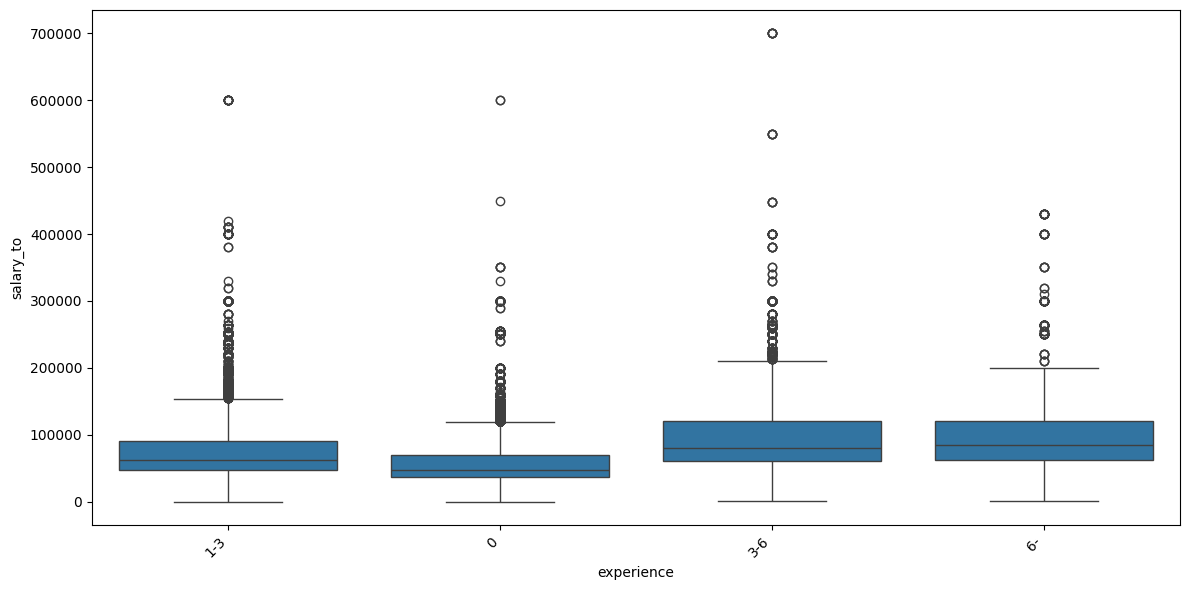

In [90]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    x=columns[1],
    y=columns[0],
    data=dataset
)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Поскольку анализируемые выборки являются независимыми, их распределение не является нормальным, а количество сравниваемых групп превышает две, для проверки статистической значимости различий был применён непараметрический критерий Краскала-Уолиса

In [91]:
dataset.groupby(columns[1], observed=False)[columns[0]].apply(list)

,salary_to
experience,
0,"[110000, 50000, 50000, 35000, 35000, 36000, 36..."
1-3,"[100000, 100000, 100000, 100000, 100000, 10000..."
3-6,"[150000, 150000, 150000, 105000, 105000, 60000..."
6-,"[264687, 264687, 264687, 264687, 70000, 70000,..."


In [92]:
stats.kruskal(*dataset.groupby(columns[1], observed=False)[columns[0]].apply(list))

KruskalResult(statistic=np.float64(9597.196765433107), pvalue=np.float64(0.0))

* О возможной взаимосвязи признаков:
  
    - Присутствует статистически значимая взаимосвязь между количественным признаком и категориальным

    - Тест Краскела-Уоллис показал статистически значимые различия (p < 0.05), что позволяет отвергнуть нулевую гипотезу об отсутствии различий между группами

* В разрезе основного признака:

  - В среднем самые большие макс.ЗП у 6- и 3-6

  - В среднем самые маленькие макс.ЗП у 0

  - В медиане самые большие макс.ЗП у 6- и 3-6
  
  - В медиане самые маленькие макс.ЗП у 0

  - В среднем чем больше опыт, тем больше максимальная зарплата

### 16.12 Признаки salary_to и schedule

**Нулевая гипотеза (H₀): распределения двух независимых выборок идентичны. Уровень значимости полагаем равным 0,05**

Сохраним именна переменных в кортеж columns

In [93]:
columns = ('salary_to', 'schedule')

Оценим медианные значения данного количественного признака в разрезе данного категориального

In [94]:
dataset.groupby(columns[1], observed=False)[columns[0]].median()

,salary_to
schedule,
flexible,55318.0
full_day,61829.0
labor,120000.0
remote,70000.0
shift,45395.0


Оценим средние значения данного количественного признака в разрезе данного категориального

In [95]:
dataset.groupby(columns[1], observed=False)[columns[0]].mean()

,salary_to
schedule,
flexible,72518.685758
full_day,71314.769030
labor,122228.857431
remote,93584.047634
shift,49885.437691


Оценим описательные данного количественного признака в разрезе данного категориального

In [96]:
dataset.groupby(columns[1], observed=False)[columns[0]].describe()

,count,mean,std,min,25%,50%,75%,max
schedule,,,,,,,,
flexible,3265.0,72518.685758,48204.259432,4800.0,43084.0,55318.0,90000.0,300000.0
full_day,60168.0,71314.769030,40685.234777,25.0,45000.0,61829.0,85000.0,700000.0
labor,5948.0,122228.857431,41407.491547,2500.0,97000.0,120000.0,150000.0,450000.0
remote,3212.0,93584.047634,69375.289282,1000.0,47377.0,70000.0,110000.0,400000.0
shift,8819.0,49885.437691,23141.609763,45.0,36028.0,45395.0,55000.0,350000.0


Построим диаграммы "ящик с усами" с помощью метода boxplot(), передав в качестве x - данный категориальный признак, а в качестве y - данный количественный признак

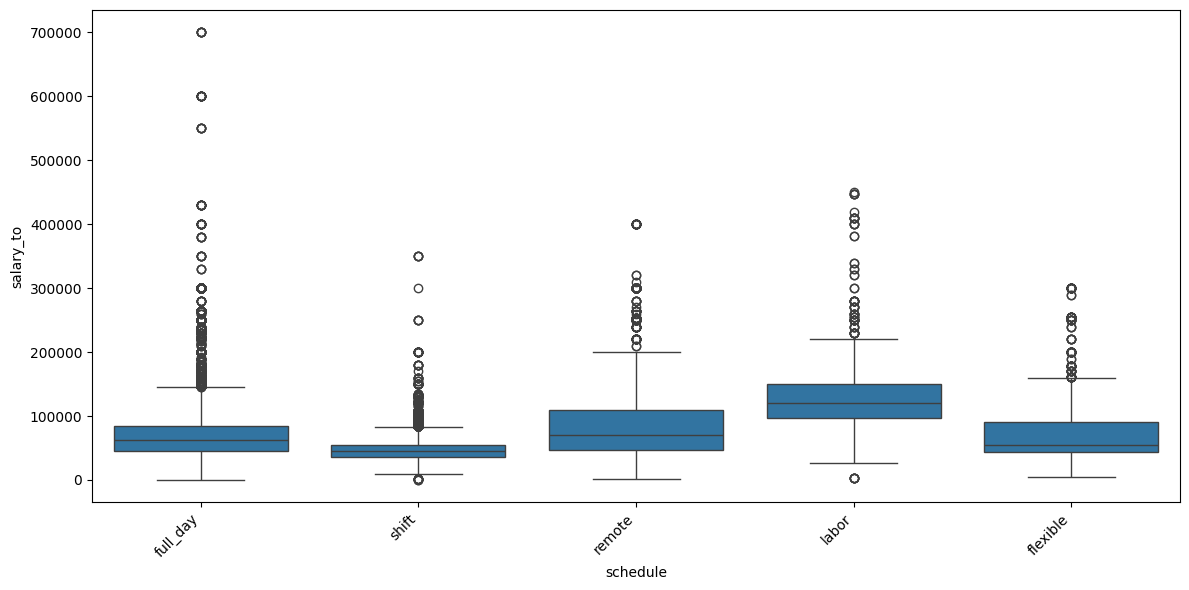

In [97]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    x=columns[1],
    y=columns[0],
    data=dataset
)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Поскольку анализируемые выборки являются независимыми, их распределение не является нормальным, а количество сравниваемых групп превышает две, для проверки статистической значимости различий был применён непараметрический критерий Краскала-Уолиса

In [98]:
dataset.groupby(columns[1], observed=False)[columns[0]].apply(list)

,salary_to
schedule,
flexible,"[85000, 85000, 27000, 27000, 27000, 27000, 450..."
full_day,"[100000, 100000, 100000, 100000, 100000, 10000..."
labor,"[150000, 150000, 150000, 105000, 105000, 16000..."
remote,"[50000, 50000, 84520, 170000, 170000, 170000, ..."
shift,"[110000, 35000, 35000, 28701, 28701, 28701, 28..."


In [99]:
stats.kruskal(*dataset.groupby(columns[1], observed=False)[columns[0]].apply(list))

KruskalResult(statistic=np.float64(12052.848547877831), pvalue=np.float64(0.0))

* О возможной взаимосвязи признаков:
  
    - Присутствует статистически значимая взаимосвязь между количественным признаком и категориальным

    - Тест Краскела-Уоллис показал статистически значимые различия (p < 0.05), что позволяет отвергнуть нулевую гипотезу об отсутствии различий между группами

* В разрезе основнго признака

    - В среднем самые большие макс.ЗП у remote и labor

    - В среднем самые маленькие макс.ЗП у shift

    - В медиане самые большие макс.ЗП у labor

    - В медиане самые маленькие макс.ЗП у shift

    - В целом сотрудникам с графиком labor готовы предложить значительно больше, чем по другим графикам

### 16.13 Признаки salary_to и employment

**Нулевая гипотеза (H₀): распределения двух независимых выборок идентичны. Уровень значимости полагаем равным 0,05**

Сохраним именна переменных в кортеж columns

In [100]:
columns = ('salary_to', 'employment')

Оценим медианные значения данного количественного признака в разрезе данного категориального

In [101]:
dataset.groupby(columns[1], observed=False)[columns[0]].median()

,salary_to
employment,
full,61829.0
part,46968.0
probation,61829.0
project,80000.0


Оценим средние значения данного количественного признака в разрезе данного категориального

In [102]:
dataset.groupby(columns[1], observed=False)[columns[0]].mean()

,salary_to
employment,
full,74419.992331
part,59736.821080
probation,77278.980707
project,82701.653061


Оценим описательные данного количественного признака в разрезе данного категориального

In [103]:
dataset.groupby(columns[1], observed=False)[columns[0]].describe()

,count,mean,std,min,25%,50%,75%,max
employment,,,,,,,,
full,75885.0,74419.992331,44020.373035,25.0,45000.0,61829.0,90000.0,700000.0
part,4611.0,59736.821080,42459.749444,25.0,35000.0,46968.0,80000.0,300000.0
probation,622.0,77278.980707,46276.095662,15000.0,50332.0,61829.0,97812.0,300000.0
project,294.0,82701.653061,42089.560656,5700.0,55318.0,80000.0,100000.0,250000.0


Построим диаграммы "ящик с усами" с помощью метода boxplot(), передав в качестве x - данный категориальный признак, а в качестве y - данный количественный признак

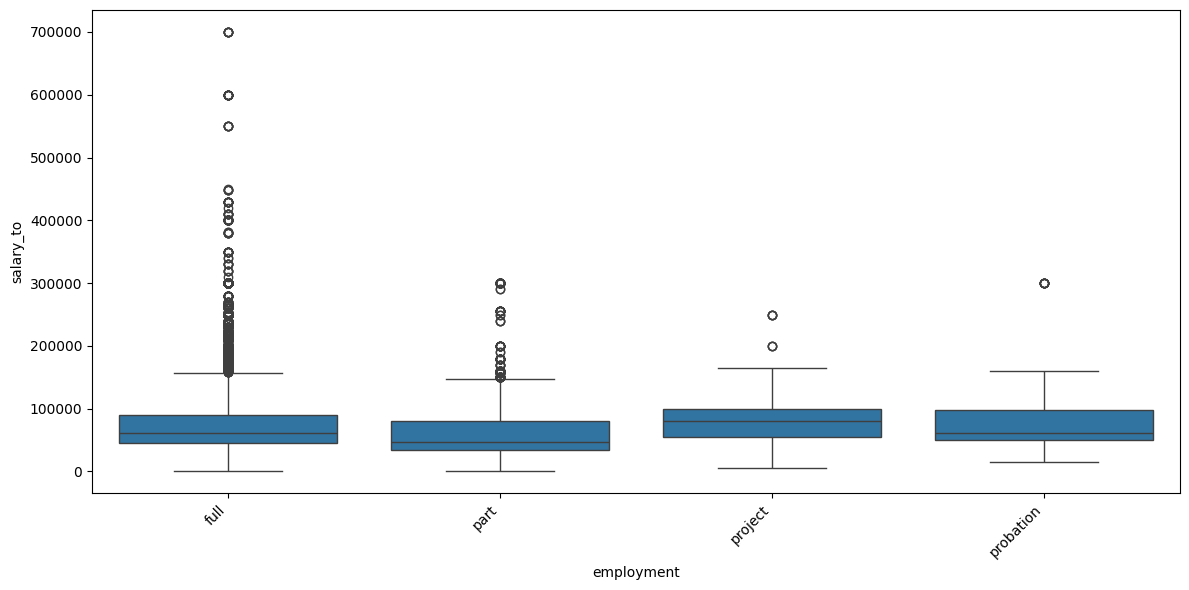

In [104]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    x=columns[1],
    y=columns[0],
    data=dataset
)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Поскольку анализируемые выборки являются независимыми, их распределение не является нормальным, а количество сравниваемых групп превышает две, для проверки статистической значимости различий был применён непараметрический критерий Краскала-Уолиса

In [105]:
dataset.groupby(columns[1], observed=False)[columns[0]].apply(list)

,salary_to
employment,
full,"[100000, 100000, 100000, 100000, 100000, 10000..."
part,"[110000, 50000, 50000, 28701, 28701, 28701, 28..."
probation,"[84520, 84520, 84520, 84520, 84520, 40000, 400..."
project,"[30500, 36793, 36793, 36793, 45000, 45000, 450..."


In [106]:
stats.kruskal(*dataset.groupby(columns[1], observed=False)[columns[0]].apply(list))

KruskalResult(statistic=np.float64(919.1838100927382), pvalue=np.float64(6.107797999512406e-199))

* О возможной взаимосвязи признаков:
  
    - Присутствует статистически значимая взаимосвязь между количественным признаком и категориальным

    - Тест Краскела-Уоллис показал статистически значимые различия (p < 0.05), что позволяет отвергнуть нулевую гипотезу об отсутствии различий между группами

* В разрезе основнго признака

    - В среднем самые большие макс.ЗП у project и probation

    - В среднем самые маленькие макс.ЗП у part

    - В медиане самые большие макс.ЗП у project

    - В медиане самые маленькие макс.ЗП у part

### 16.14 Признаки salary_to и accept_handicapped

**Нулевая гипотеза (H₀): распределения двух независимых выборок идентичны. Уровень значимости полагаем равным 0,05**

Сохраним именна переменных в кортеж columns

In [107]:
columns = ('salary_to', 'accept_handicapped')

Оценим медианные значения данного количественного признака в разрезе данного категориального

In [108]:
dataset.groupby(columns[1], observed=False)[columns[0]].median()

,salary_to
accept_handicapped,
0,61829.0
1,60000.0


Оценим средние значения данного количественного признака в разрезе данного категориального

In [109]:
dataset.groupby(columns[1], observed=False)[columns[0]].mean()

,salary_to
accept_handicapped,
0,73438.885710
1,85025.058699


Оценим описательные данного количественного признака в разрезе данного категориального

In [110]:
dataset.groupby(columns[1], observed=False)[columns[0]].describe()

,count,mean,std,min,25%,50%,75%,max
accept_handicapped,,,,,,,,
0,79998.0,73438.885710,43315.546619,25.0,45000.0,61829.0,90000.0,700000.0
1,1414.0,85025.058699,74760.741686,1800.0,44596.0,60000.0,100000.0,600000.0


Построим диаграммы "ящик с усами" с помощью метода boxplot(), передав в качестве x - данный категориальный признак, а в качестве y - данный количественный признак

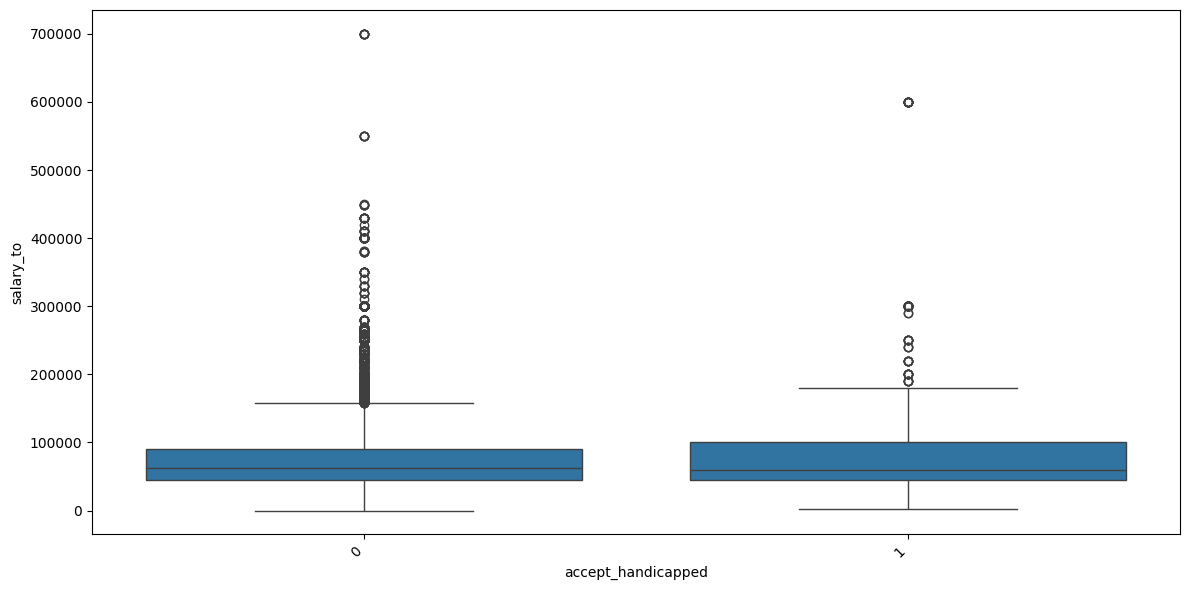

In [111]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    x=columns[1],
    y=columns[0],
    data=dataset
)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Поскольку анализируемые выборки являются независимыми, их распределение не является нормальным, а количество сравниваемых групп не превышает две, для проверки статистической значимости различий был применён непараметрический критерий Манна-Уитни

In [112]:
dataset.groupby(columns[1], observed=False)[columns[0]].apply(list)

,salary_to
accept_handicapped,
0,"[100000, 100000, 100000, 100000, 100000, 10000..."
1,"[50000, 50000, 27000, 27000, 27000, 27000, 300..."


In [113]:
stats.mannwhitneyu(*dataset.groupby(columns[1], observed=False)[columns[0]].apply(list))

MannwhitneyuResult(statistic=np.float64(55273624.5), pvalue=np.float64(0.14233142831808085))

* О возможной взаимосвязи признаков:
  
    - Отсутствует статистически значимая взаимосвязь между количественным признаком и категориальным

    - Тест Манна-Уитни не показал статистически значимые различия (p > 0.05), что позволяет принять нулевую гипотезу об отсутствии различий между группами

* В разрезе основнго признака

    - В среднем самые большие макс.ЗП у соискателей с инвалидностью

    - В среднем самые маленькие макс.ЗП у соискателей без инвалидности

    - В медиане самые большие макс.ЗП у соискателей без инвалидности

    - В медиане самые маленькие макс.ЗП у соискателей с инвалидностью

### 16.15 Признаки salary_to и city

**Нулевая гипотеза (H₀): распределения двух независимых выборок идентичны. Уровень значимости полагаем равным 0,05**

Сохраним именна переменных в кортеж columns

In [114]:
columns = ('salary_to', 'city')

Оценим медианные значения данного количественного признака в разрезе данного категориального

In [115]:
dataset.groupby(columns[1], observed=False)[columns[0]].median()

,salary_to
city,
Александровское (Томская область),60702.0
Асино,59478.5
Бакчар,77500.0
Батурино,130000.0
Белый Яр,80000.0
Богашёво,70000.0
Зональная Станция,48000.0
Зоркальцево,70000.0
Зырянское,29000.0


Оценим средние значения данного количественного признака в разрезе данного категориального

In [116]:
dataset.groupby(columns[1], observed=False)[columns[0]].mean()

,salary_to
city,
Александровское (Томская область),69189.469231
Асино,61217.202020
Бакчар,81836.207317
Батурино,106538.461538
Белый Яр,88044.268293
Богашёво,80979.921875
Зональная Станция,63138.315789
Зоркальцево,77494.729167
Зырянское,48459.245763


Оценим описательные данного количественного признака в разрезе данного категориального

In [117]:
dataset.groupby(columns[1], observed=False)[columns[0]].describe()

,count,mean,std,min,25%,50%,75%,max
city,,,,,,,,
Александровское (Томская область),130.0,69189.469231,29987.205279,4800.0,45000.0,60702.0,82461.00,130000.0
Асино,396.0,61217.202020,28568.977047,22000.0,40000.0,59478.5,75094.00,160000.0
Бакчар,82.0,81836.207317,32111.133685,25000.0,60000.0,77500.0,105000.00,160000.0
Батурино,13.0,106538.461538,52097.049476,45000.0,45000.0,130000.0,160000.00,160000.0
Белый Яр,82.0,88044.268293,43003.011553,28353.0,60000.0,80000.0,110000.00,200000.0
Богашёво,64.0,80979.921875,35802.963886,32000.0,60000.0,70000.0,110000.00,160000.0
Зональная Станция,152.0,63138.315789,33414.541099,25000.0,40000.0,48000.0,74310.00,160000.0
Зоркальцево,48.0,77494.729167,40377.477986,20000.0,45000.0,70000.0,110000.00,160000.0
Зырянское,118.0,48459.245763,33141.271763,25000.0,29000.0,29000.0,53480.00,160000.0


Построим диаграммы "ящик с усами" с помощью метода boxplot(), передав в качестве x - данный категориальный признак, а в качестве y - данный количественный признак

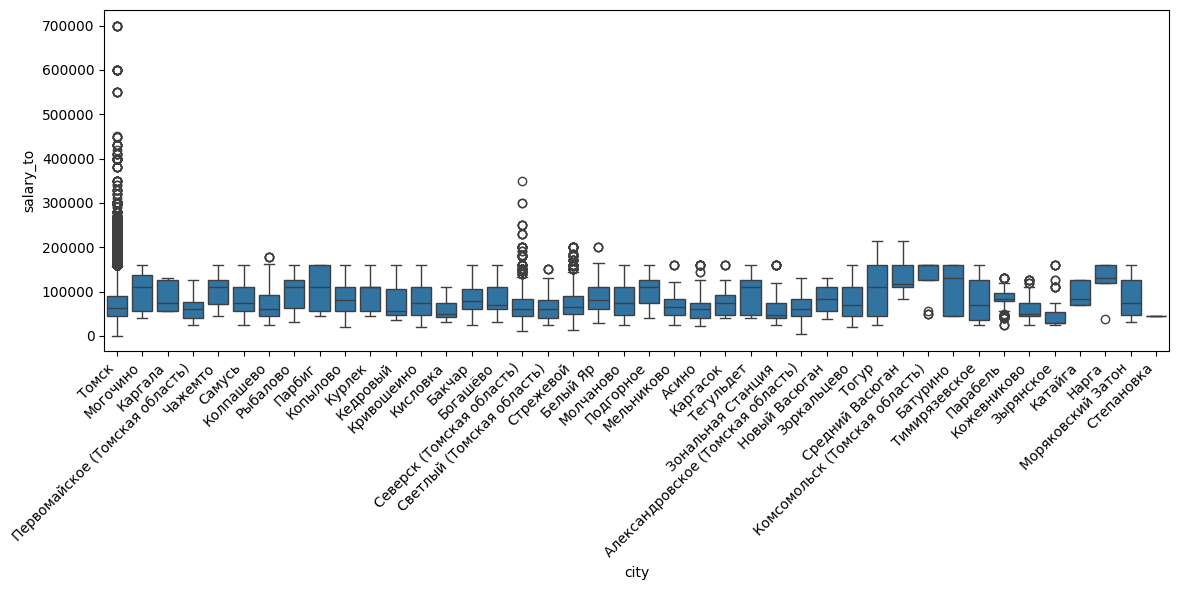

In [118]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    x=columns[1],
    y=columns[0],
    data=dataset
)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Поскольку анализируемые выборки являются независимыми, их распределение не является нормальным, а количество сравниваемых групп превышает две, для проверки статистической значимости различий был применён непараметрический критерий Краскала-Уолиса

In [119]:
dataset.groupby(columns[1], observed=False)[columns[0]].apply(list)

,salary_to
city,
Александровское (Томская область),"[75000, 75000, 75000, 75000, 75000, 75000, 618..."
Асино,"[85654, 85654, 85654, 85654, 85654, 85654, 856..."
Бакчар,"[60000, 60000, 60000, 60000, 60000, 60000, 600..."
Батурино,"[160000, 160000, 160000, 160000, 130000, 13000..."
Белый Яр,"[110000, 110000, 64238, 64238, 64238, 64238, 6..."
Богашёво,"[60000, 60000, 60000, 60000, 60000, 60000, 600..."
Зональная Станция,"[45000, 45000, 45000, 45000, 48000, 48000, 480..."
Зоркальцево,"[20000, 20000, 20000, 160000, 160000, 160000, ..."
Зырянское,"[25000, 25000, 25000, 110000, 110000, 40000, 4..."


In [120]:
stats.kruskal(*dataset.groupby(columns[1], observed=False)[columns[0]].apply(list))

KruskalResult(statistic=np.float64(562.7513432352046), pvalue=np.float64(7.233682670547769e-93))

* О возможной взаимосвязи признаков:
  
    - Присутствует статистически значимая взаимосвязь между количественным признаком и категориальным

    - Тест Краскала-Уолиса не показал статистически значимые различия (p < 0.05), что позволяет принять нулевую гипотезу об отсутствии различий между группами

* В разрезе основнго признака

    - В среднем самые большие макс.ЗП в Среднем Васюгане

    - В среднем самые маленькие макс.ЗП  в Степановке

    - В медиане самые большие макс.ЗП в Комсомольске (Томская область)

    - В медиане самые маленькие макс.ЗП в Зырянском

### 16.16 Признаки salary_to и field_of_activity

**Нулевая гипотеза (H₀): распределения двух независимых выборок идентичны. Уровень значимости полагаем равным 0,05**

Сохраним именна переменных в кортеж columns

In [121]:
columns = ('salary_to', 'field_of_activity')

Оценим медианные значения данного количественного признака в разрезе данного категориального

In [122]:
dataset.groupby(columns[1], observed=False)[columns[0]].median()

,salary_to
field_of_activity,
IT и технологии,143023.0
Аналитика и исследования,97812.0
Бытовые услуги,27000.0
Другие сферы,61829.0
Инженерия и строительство,77733.0
Маркетинг и реклама,60000.0
Медицина и фармацевтика,75000.0
Образование и наука,43084.0
Производство и технические специальности,88478.0


Оценим средние значения данного количественного признака в разрезе данного категориального

In [123]:
dataset.groupby(columns[1], observed=False)[columns[0]].mean()

,salary_to
field_of_activity,
IT и технологии,129288.385926
Аналитика и исследования,97531.458755
Бытовые услуги,39043.227823
Другие сферы,64922.135990
Инженерия и строительство,86241.807146
Маркетинг и реклама,64032.716057
Медицина и фармацевтика,73222.401554
Образование и наука,47328.488073
Производство и технические специальности,84969.420984


Оценим описательные данного количественного признака в разрезе данного категориального

In [124]:
dataset.groupby(columns[1], observed=False)[columns[0]].describe()

,count,mean,std,min,25%,50%,75%,max
field_of_activity,,,,,,,,
IT и технологии,4988.0,129288.385926,68931.517718,1800.0,60348.0,143023.0,159807.0,600000.0
Аналитика и исследования,691.0,97531.458755,33678.680500,29500.0,97812.0,97812.0,97812.0,350000.0
Бытовые услуги,992.0,39043.227823,23600.315191,5000.0,24526.5,27000.0,50000.0,150000.0
Другие сферы,7302.0,64922.135990,34348.024146,50.0,50000.0,61829.0,61829.0,350000.0
Инженерия и строительство,9292.0,86241.807146,33717.237497,69.0,65015.0,77733.0,100000.0,270000.0
Маркетинг и реклама,1613.0,64032.716057,36073.718988,10000.0,45000.0,60000.0,68986.0,300000.0
Медицина и фармацевтика,3733.0,73222.401554,38223.434835,40.0,41468.0,75000.0,82461.0,450000.0
Образование и наука,2096.0,47328.488073,23082.675809,25.0,35000.0,43084.0,58672.0,280000.0
Производство и технические специальности,5347.0,84969.420984,39335.979674,18000.0,60000.0,88478.0,97000.0,448000.0


Построим диаграммы "ящик с усами" с помощью метода boxplot(), передав в качестве x - данный категориальный признак, а в качестве y - данный количественный признак

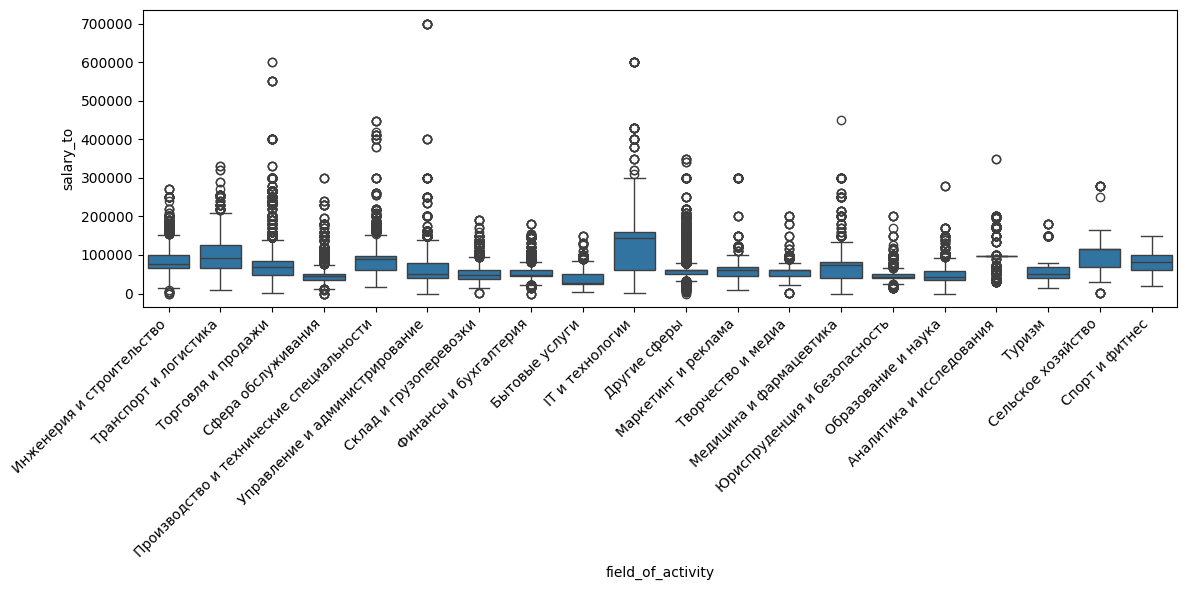

In [125]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    x=columns[1],
    y=columns[0],
    data=dataset
)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Поскольку анализируемые выборки являются независимыми, их распределение не является нормальным, а количество сравниваемых групп превышает две, для проверки статистической значимости различий был применён непараметрический критерий Краскала-Уолиса

In [126]:
dataset.groupby(columns[1], observed=False)[columns[0]].apply(list)

,salary_to
field_of_activity,
IT и технологии,"[250000, 250000, 250000, 250000, 50000, 50000,..."
Аналитика и исследования,"[170000, 170000, 170000, 170000, 170000, 17000..."
Бытовые услуги,"[45000, 29000, 10000, 10000, 10000, 10000, 100..."
Другие сферы,"[47300, 47300, 47300, 70000, 70000, 70000, 700..."
Инженерия и строительство,"[100000, 100000, 100000, 100000, 100000, 10000..."
Маркетинг и реклама,"[70000, 70000, 70000, 70000, 54000, 54000, 540..."
Медицина и фармацевтика,"[82461, 82461, 82461, 82461, 39859, 39859, 398..."
Образование и наука,"[45000, 45000, 45000, 45000, 45000, 43084, 430..."
Производство и технические специальности,"[60000, 60000, 60000, 65764, 65764, 65764, 600..."


In [127]:
stats.kruskal(*dataset.groupby(columns[1], observed=False)[columns[0]].apply(list))

KruskalResult(statistic=np.float64(21816.78549070044), pvalue=np.float64(0.0))

* О возможной взаимосвязи признаков:
  
    - Присутствует статистически значимая взаимосвязь между количественным признаком и категориальным

    - Тест Краскала-Уолиса не показал статистически значимые различия (p < 0.05), что позволяет принять нулевую гипотезу об отсутствии различий между группами

* В разрезе основнго признака

    - В среднем самые большие макс.ЗП в сфере "IT и технологии"

    - В среднем самые маленькие макс.ЗП  в сфере "Бытовые услуги"

    - В медиане самые большие макс.ЗП в сфере "IT и технологии"

    - В медиане самые маленькие макс.ЗП в сфере "Бытовые услуги"